# Supply Chain Delay Predictor
## End-to-End MLOps Pipeline

Team: Team Hedwig
Event:The Hitchhiker's Guide to MLOps
Dataset: E-Commerce Shipping Dataset - Kaggle

In [1]:
import pandas as pd
df = pd.read_csv('data/Train.csv')
print(df.shape)
df.head()


(10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


1. Exploratory Data Analysis (EDA)
Understanding the dataset — shape, columns, missing values and patterns  


In [2]:
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']

Data types:
ID                     int64
Warehouse_block          str
Mode_of_Shipment         str
Customer_care_calls    int64
Customer_rating        int64
Cost_of_the_Product    int64
Prior_purchases        int64
Product_importance       str
Gender                   str
Discount_offered       int64
Weight_in_gms          int64
Reached.on.Time_Y.N    int64
dtype: object

Missing values:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [2]:
# Check target column distribution
print("Shipment Delay Distribution:")
print(df['Reached.on.Time_Y.N'].value_counts())
print("\nPercentage:")
print(df['Reached.on.Time_Y.N'].value_counts(normalize=True)*100)

Shipment Delay Distribution:
Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

Percentage:
Reached.on.Time_Y.N
1    59.669061
0    40.330939
Name: proportion, dtype: float64


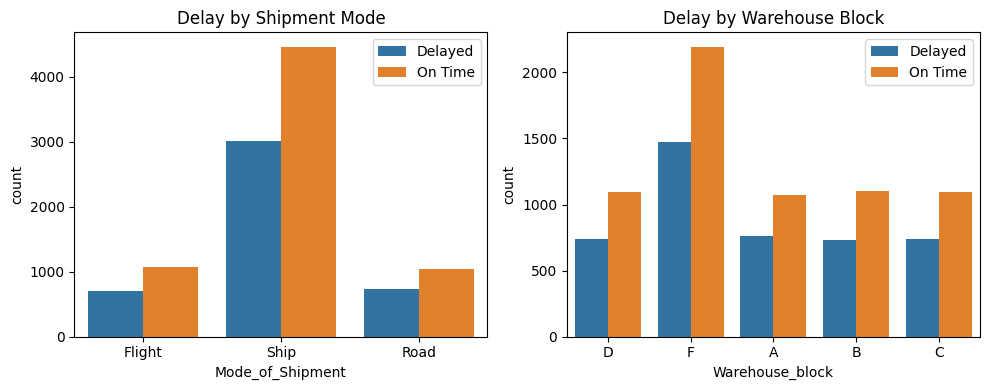

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1 - Delay by Shipment Mode
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(data=df, x='Mode_of_Shipment', hue='Reached.on.Time_Y.N')
plt.title('Delay by Shipment Mode')
plt.legend(['Delayed','On Time'])

# Plot 2 - Delay by Warehouse Block
plt.subplot(1,2,2)
sns.countplot(data=df, x='Warehouse_block', hue='Reached.on.Time_Y.N')
plt.title('Delay by Warehouse Block')
plt.legend(['Delayed','On Time'])

plt.tight_layout()
plt.savefig('eda_plot1.png')
plt.show()

In [5]:
import sys
print(sys.executable)


c:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe


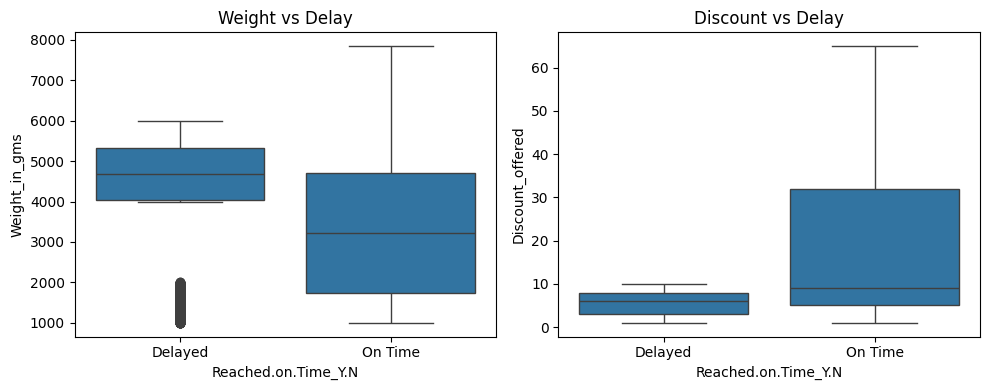

In [4]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(data=df, x='Reached.on.Time_Y.N', y='Weight_in_gms')
plt.title('Weight vs Delay')
plt.xticks([0,1], ['Delayed','On Time'])

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Reached.on.Time_Y.N', y='Discount_offered')
plt.title('Discount vs Delay')
plt.xticks([0,1], ['Delayed','On Time'])

plt.tight_layout()
plt.savefig('eda_plot2.png')
plt.show()

In [5]:
print("=== KEY INSIGHTS ===")
print("\nDelay rate by Shipment Mode:")
print(df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].apply(lambda x: (x==0).mean()*100).round(2).astype(str) + '%')

print("\nDelay rate by Warehouse Block:")
print(df.groupby('Warehouse_block')['Reached.on.Time_Y.N'].apply(lambda x: (x==0).mean()*100).round(2).astype(str) + '%')

print("\nAverage weight - Delayed vs On Time:")
print(df.groupby('Reached.on.Time_Y.N')['Weight_in_gms'].mean().round(2))

print("\nAverage discount - Delayed vs On Time:")
print(df.groupby('Reached.on.Time_Y.N')['Discount_offered'].mean().round(2))

=== KEY INSIGHTS ===

Delay rate by Shipment Mode:
Mode_of_Shipment
Flight    39.84%
Road      41.19%
Ship      40.24%
Name: Reached.on.Time_Y.N, dtype: object

Delay rate by Warehouse Block:
Warehouse_block
A    41.35%
B    39.77%
C    40.32%
D    40.24%
F    40.15%
Name: Reached.on.Time_Y.N, dtype: object

Average weight - Delayed vs On Time:
Reached.on.Time_Y.N
0    4168.67
1    3272.64
Name: Weight_in_gms, dtype: float64

Average discount - Delayed vs On Time:
Reached.on.Time_Y.N
0     5.55
1    18.66
Name: Discount_offered, dtype: float64


 EDA Summary
- No missing values found in the dataset
- Overall delay rate: ~40% of all shipments
- Shipment mode and warehouse block show similar delay rates (~40%) across all categories
- **Key finding 1:** Discount is strongest predictor — delayed shipments avg 5.55% discount vs 18.66% for on-time
- Key finding 2: Weight matters — delayed shipments avg 4168gms vs 3272gms for on-time
- Customer care calls, prior purchases, ratings also collected but delay rate uniform across modes/warehouses

In [6]:
# Feature Engineering
# Why: ML models only understand numbers, not text like "Ship" or "Flight"

from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Drop ID - it's just a row number, not useful for prediction
df_model = df_model.drop('ID', axis=1)

# Convert text columns to numbers
le = LabelEncoder()
df_model['Warehouse_block'] = le.fit_transform(df_model['Warehouse_block'])
df_model['Mode_of_Shipment'] = le.fit_transform(df_model['Mode_of_Shipment'])
df_model['Product_importance'] = le.fit_transform(df_model['Product_importance'])
df_model['Gender'] = le.fit_transform(df_model['Gender'])

print("Features ready:")
print(df_model.dtypes)
print("\nFirst row sample:")
print(df_model.head(1))

Features ready:
Warehouse_block        int64
Mode_of_Shipment       int64
Customer_care_calls    int64
Customer_rating        int64
Cost_of_the_Product    int64
Prior_purchases        int64
Product_importance     int64
Gender                 int64
Discount_offered       int64
Weight_in_gms          int64
Reached.on.Time_Y.N    int64
dtype: object

First row sample:
   Warehouse_block  Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0                3                 0                    4                2   

   Cost_of_the_Product  Prior_purchases  Product_importance  Gender  \
0                  177                3                   1       0   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44           1233                    1  
